In [8]:
from importlib import reload
import os
import glob
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(r"../main_code/2d")

import visual
import net_2d
import error_general_2d
reload(visual)
reload(net_2d)

torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
cupy_device = device.index if device.type == "cuda" else 0
print(device)

noise_dir = "./noise=5%"
tau_x_min, tau_x_max = 0.0, 1.0
tau_y_min, tau_y_max = 0.0, 1.0
Qx, Qy = 301, 301
selected_idx = 4  # 5.ipynb picked L-curve candidate index 4.

cuda:2


In [9]:
def _composite_source_xy(X, Y):
    x1, y1 = 0.42, 0.45
    rho1 = np.sqrt((X - x1)**2 + (Y - y1)**2)
    theta1 = np.arctan2(Y - y1, X - x1)
    R1 = 0.18 + 0.035*np.cos(5*theta1) - 0.012*np.sin(3*theta1)
    f1 = -1.00 * (rho1 <= R1).astype(float)

    x2, y2 = 0.22, 0.76
    angle2 = -np.pi / 12.0   # 旋转一下方向，可自行调

    Xc2 = X - x2
    Yc2 = Y - y2
    Xp2 =  Xc2 * np.cos(angle2) + Yc2 * np.sin(angle2)
    Yp2 = -Xc2 * np.sin(angle2) + Yc2 * np.cos(angle2)

    rho2 = np.sqrt(Xp2**2 + Yp2**2)
    theta2 = np.arctan2(Yp2, Xp2)

    # 上窄下宽的水滴半径
    R2 = 0.08 * (1.1 - 0.8 * np.sin(theta2) + 0.2 * np.cos(1.8*theta2))
    R2 = np.maximum(R2, 0.015)
    f2 = 0.80 * (rho2 <= R2).astype(float)


    x3, y3 = 0.75, 0.36
    rho3 = np.sqrt((X - x3)**2 + (Y - y3)**2)
    theta3 = np.arctan2(Y - y3, X - x3)
    R3 = 0.08 + 0.012*np.cos(4*theta3) + 0.008*np.sin(6*theta3)
    f3 = 1 * (rho3 <= R3).astype(float)

    x4, y4 = 0.80, 0.78
    angle4 = np.pi / 8.0
    Xc4 = X - x4
    Yc4 = Y - y4
    Xp4 = Xc4 * np.cos(angle4) + Yc4 * np.sin(angle4)
    Yp4 = -Xc4 * np.sin(angle4) + Yc4 * np.cos(angle4)
    rho4 = np.sqrt(Xp4**2 + Yp4**2)
    theta4 = np.arctan2(Yp4, Xp4)
    R4 = 0.1 * (1.0 - 0.55 * np.cos(2 * theta4) + 0.08 * np.sin(theta4))
    R4 = np.maximum(R4, 0.015)
    f4 = -0.80 * (rho4 <= R4).astype(float)

    return f1 + f2 + f3 + f4


def composite_source(points, x_left=None, x_right=None, y_below=None, y_upper=None, center=None, r=None):
    points = np.asarray(points)
    return _composite_source_xy(points[:, 0], points[:, 1])


x = np.linspace(tau_x_min, tau_x_max, Qx)
y = np.linspace(tau_y_min, tau_y_max, Qy)
X, Y = np.meshgrid(x, y, indexing="ij")
sample_s_np = np.column_stack((X.ravel(), Y.ravel()))
S_true = composite_source(sample_s_np).reshape(Qx, Qy)
true_support = (np.abs(S_true) > 1e-12).astype(float)

Plot saved as ./noise=5%/irregular_true_source.pdf


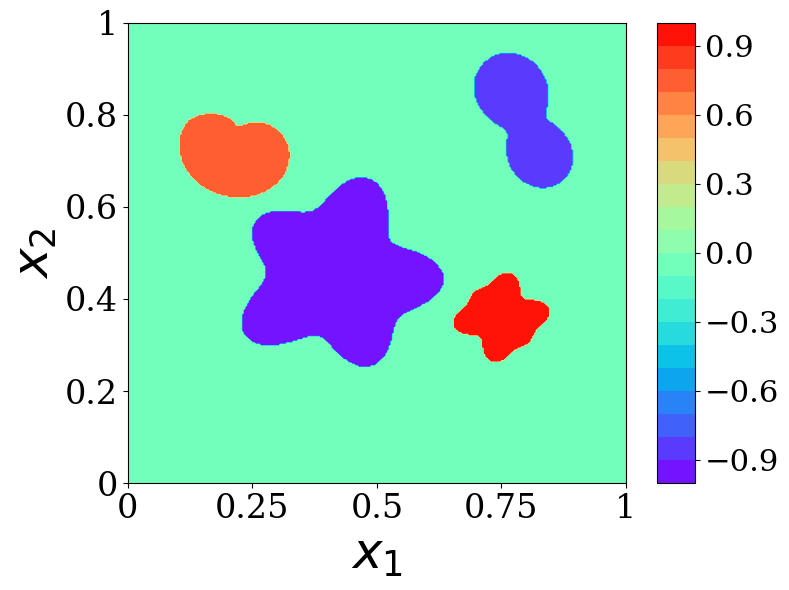

In [10]:
reload(visual)
visual.draw(
    X,
    Y,
    S_true,
    noise_dir,
    "irregular_true_source.pdf",
    label_size=36,
    tick_size=24,
    colorbar_tick_size=22,
)

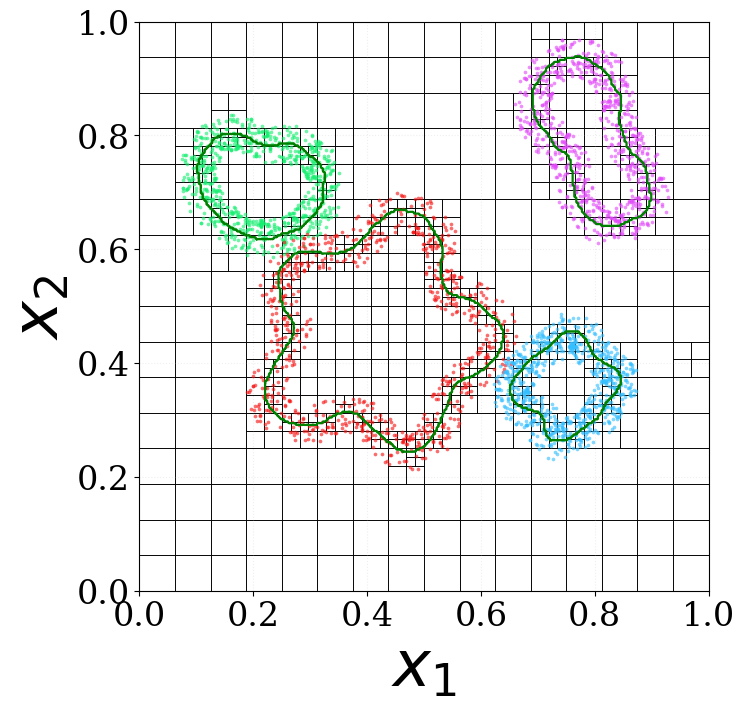

noise models: ['noise_model_sig_0.pth', 'noise_model_sig_1.pth', 'noise_model_sig_2.pth', 'noise_model_sig_3.pth']


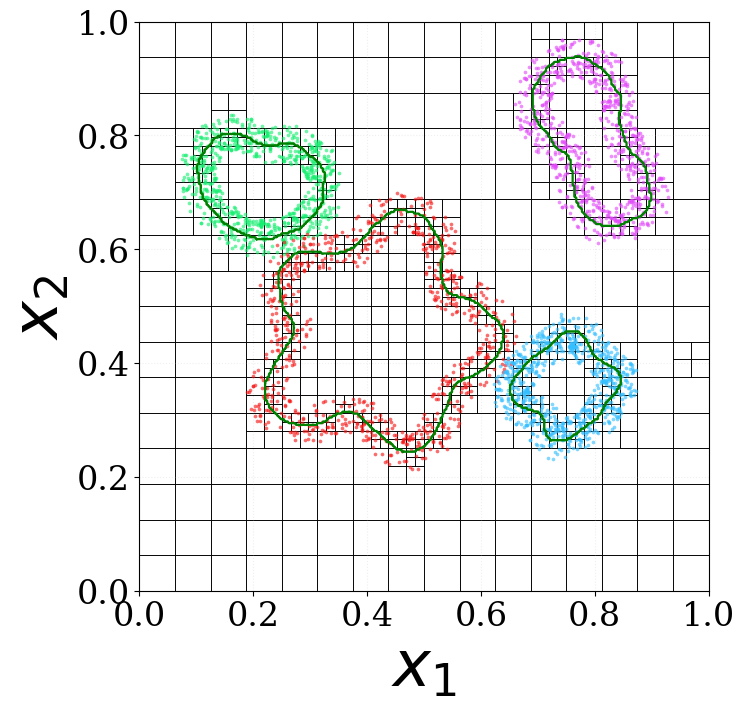

In [11]:
reload(visual)

detected_results_for_plot = globals().get("results", None)
if detected_results_for_plot is None:
    detected_results_for_plot = []
    if "general_results" in globals():
        detected_results_for_plot.extend(general_results)
    if "regular_result" in globals() and regular_result is not None:
        detected_results_for_plot.append(regular_result)
    if len(detected_results_for_plot) == 0:
        detected_results_for_plot = None

s_num_for_boundaries = None
s_num_path = os.path.join(noise_dir, "S_num.npy")
if detected_results_for_plot is None and os.path.exists(s_num_path):
    s_num_for_boundaries = np.load(s_num_path)

visual.plot_cell_mesh_and_noise_centers(
    cells_path=os.path.join(noise_dir, "cells_store_last.pkl"),
    noise_dir=noise_dir,
    output_filename="irregular_cells_and_enhance_centers.pdf",
    xlim=(tau_x_min, tau_x_max),
    ylim=(tau_y_min, tau_y_max),
    detected_results=detected_results_for_plot,
    S_num=s_num_for_boundaries,
    detect_boundary_from_solution=s_num_for_boundaries is not None,
    para_abs=3.0,
    para_grad=3.0,
    eps=5.0,
    mini_samples=20,
    min_cluster_size=200,
    show_legend=False,
    label_size=46,
    tick_size=24,
)

In [12]:
# The adaptive cell mesh and local circular-basis centers are plotted together above.


In [13]:
S_num=np.load("./noise=5%/S_num.npy")

Plot saved as ./noise=5%/irregular_num_idx4.pdf


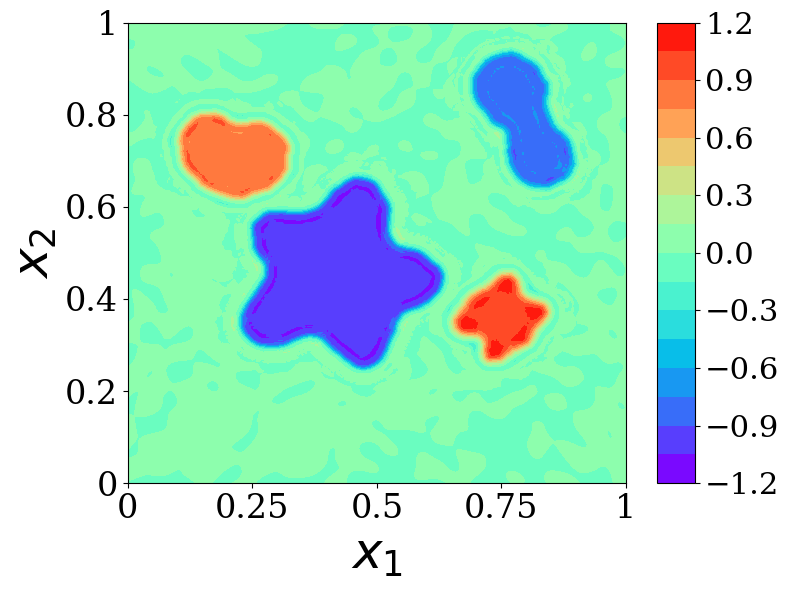

Plot saved as ./noise=5%/irrgular_error_idx4.pdf


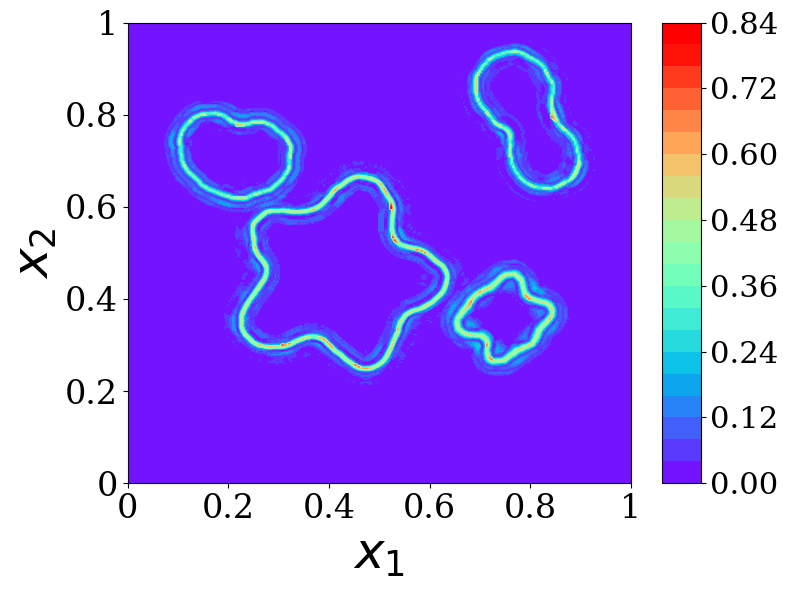

In [14]:
reload(visual)
visual.draw(
    X,
    Y,
    S_num,
    noise_dir,
    f"irregular_num_idx{selected_idx}.pdf",
    label_size=36,
    tick_size=24,
    colorbar_tick_size=22,
)
visual.draw(
    X,
    Y,
    np.abs(S_true - S_num),
    noise_dir,
    f"irrgular_error_idx{selected_idx}.pdf",
    label_size=36,
    tick_size=24,
    colorbar_tick_size=22,
)